
📊 INITIAL DATA SCIENTIFIC PROFILE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values Detected Matrix:
Age         177
Cabin       687
Embarked      2
dtype: int64

✅ Verification: Missing values remaining:  0


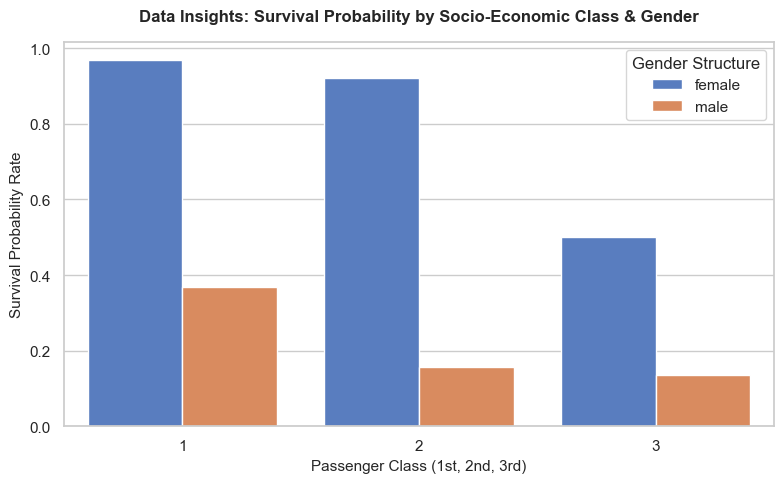

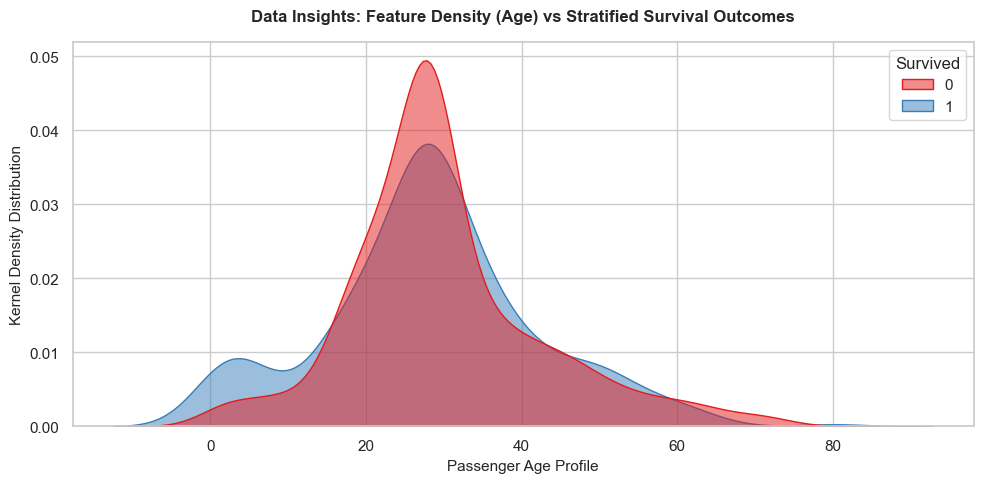

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import shutil

# Data Science Automation: Locate the file if it's trapped in a subfolder or downloads
filename = 'train.csv'

if not os.path.exists(filename):
    print("Searching for your Titanic dataset across local directory trees...")
    # Look back into downloads or extracted subdirectories automatically
    possible_paths = (
        glob.glob(os.path.expanduser('~/Downloads/titanic*/train.csv')) +
        glob.glob(os.path.expanduser('~/Downloads/train*.csv')) +
        glob.glob('**/train.csv', recursive=True) +
        glob.glob('**/train.csv.csv', recursive=True)
    )
    
    if possible_paths:
        print(f"Found it here: {possible_paths[0]}")
        # Copy it right into your current workspace to clean up environment paths
        shutil.copy(possible_paths[0], filename)
        print("Successfully synchronized data asset into Jupyter workspace environment.")
    else:
        # Fallback: Check if it's named without the extension on the backend
        if os.path.exists('train'):
            os.rename('train', 'train.csv')
            print("Fixed extension mismatch.")

# =====================================================================
# DATA SCIENCE PIPELINE EXECUTION
# =====================================================================
try:
    # 1. Load the dataset
    df = pd.read_csv('train.csv')
    sns.set_theme(style="whitegrid")

    print("\n" + "="*40)
    print("📊 INITIAL DATA SCIENTIFIC PROFILE")
    print("="*40)
    print(df.info())
    print("\nMissing Values Detected Matrix:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    # 2. Pipeline Feature Engineering & Robust Imputation
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    if 'Cabin' in df.columns:
        df.drop(columns=['Cabin'], inplace=True)

    print("\n✅ Verification: Missing values remaining: ", df.isnull().sum().sum())

    # 3. Categorical Covariate Feature Interaction Chart
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='muted', errorbar=None)
    plt.title('Data Insights: Survival Probability by Socio-Economic Class & Gender', fontsize=12, weight='bold', pad=15)
    plt.xlabel('Passenger Class (1st, 2nd, 3rd)', fontsize=11)
    plt.ylabel('Survival Probability Rate', fontsize=11)
    plt.legend(title='Gender Structure')
    plt.tight_layout()
    plt.show()

    # 4. Continuous Feature Density Visual Trend Analysis
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, common_norm=False, palette='Set1', alpha=0.5)
    plt.title('Data Insights: Feature Density (Age) vs Stratified Survival Outcomes', fontsize=12, weight='bold', pad=15)
    plt.xlabel('Passenger Age Profile', fontsize=11)
    plt.ylabel('Kernel Density Distribution', fontsize=11)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nCould not execute automated pipeline. Error: {e}")
    print("Manual fallback: Please ensure 'train' file was dragged directly into your main Jupyter dashboard list.")